# Векторные представления текстов (ноутбук)

> Узнаем, как и зачем можно делать векторные представления текстов. Учимся решать задачу классификации текста.

In [248]:
#!g1.1
import torch
import torch.nn as nn
import numpy as np

import ssl
ssl._create_default_https_context = ssl.create_default_context

In [249]:
#!g1.1
import gensim.downloader as api

### качаем модель, более лучшая альтернатива fasttext, векторы обучены на твиттере
fasttext = api.load('glove-twitter-25')

In [250]:
#!g1.1
### смотрим на слова которые ближе всего к слову man
fasttext.most_similar(positive=['man'])

[('was', 0.906562089920044),
 ('i', 0.8880171179771423),
 ('he', 0.8874381184577942),
 ('bad', 0.8846145868301392),
 ('even', 0.8832387924194336),
 ('be', 0.8784029483795166),
 ('we', 0.8764979839324951),
 ('not', 0.8764554262161255),
 ('had', 0.8762111067771912),
 ('glad', 0.8758710622787476)]

In [251]:
#!g1.1
### смотрим на слова которые ближе всего к комбинации, которую рассматривали на лекции
fasttext.most_similar(positive=['king', 'woman'], negative=['man'])

[('meets', 0.8841924071311951),
 ('prince', 0.8321634531021118),
 ('queen', 0.8257462382316589),
 ('’s', 0.8174097537994385),
 ('crow', 0.8134993314743042),
 ('hunter', 0.8131037950515747),
 ('father', 0.8115833401679993),
 ('soldier', 0.81113600730896),
 ('mercy', 0.8082394003868103),
 ('hero', 0.8082264065742493)]

In [291]:
#!g1.1
import re
import string
from collections import Counter

### напишем словарь для текстов, которые у нас есть
class Vocabulary:
    def __init__(self, texts: list[str], min_freq: int = 10): ### тексты приходят, как список строк, 
        ### min_freq ограничивает редко встречающиеся мусорные слова
        
        text = ' '.join(texts) ### склеиваем все тексты в один длинный список

        ### заменяем все ссылки на пустое место
        text = re.sub(r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+", " ", text)
        ### оставляем только символы буквы
        text = re.sub("[^a-zA-Z]", " ", text)

        ### заменяем два пробела на один
        while '  ' in text:
            text = text.replace('  ', ' ')

        ### обрежем все что не нужно по сторонам(пробелы и тд), приведем к нижнему регистру и посплитим по проблеам
        words = text.strip().lower().split()

        ### получили список слов после сплита и подаем в counter, которые считает слова и строит количества слов для каждого слова
        c = Counter(words)

        ### составляем множество из списка, а в списке оставляем все слова, у которых частота больше либо равна чем минимальная
        self.vocabulary = list(set([word for word in words if c[word] >= min_freq]))
        ### добавляем в словарь новый токен, который будет возвращать <unk> для тех слов, которых нет в словаре
        self.vocabulary.append('<unk>')
        ### создаем два словаря
        ### первый для перевода индекса в слово
        ### второй для перевода слова в индекс
        self._idx2word = {i: word for i, word in enumerate(self.vocabulary)}
        self._word2idx = {word: i for i, word in enumerate(self.vocabulary)}

    def get_vocabulary(self):
        return self.vocabulary

    def idx2word(self, idx: int): ### по индексу вернет слово или unk при отсутствии слова
        if idx not in self._idx2word:
            return '<unk>'

        return self._idx2word[idx]

    def word2idx(self, word: str): ### по слову вернет индекс или unk при отсутствии индекса
        word = word.lower()
        if word not in self._word2idx:
            return self._word2idx['<unk>']

        return self._word2idx[word]
    
    def encode(self, text):

        text = re.sub(r"http[s]?://\S+", " ", text)
        text = re.sub("[^a-zA-Z]", " ", text)

        while "  " in text:
            text = text.replace("  ", " ")

        words = text.strip().lower().split()

        result = []

        for word in words:
            result.append(self.word2idx(word))

        return result


    def build_vectors(self, fasttext):
        vectors = []
    
        # проходим по каждому слову нашего словаря
        for word in self.vocabulary:

            # проверяем есть ли это слово в pretrained модели (glove / fasttext)
            if fasttext.has_index_for(word):

                # если есть — берем его обученный вектор
                # например: [0.12, -0.4, 0.55, ...]
                vectors.append(fasttext[word])

            else:
                # если слова нет в pretrained embeddings
                # добавляем нулевой вектор размерности 25
                # чтобы размер матрицы оставался одинаковым
                vectors.append(np.zeros(25))

        # превращаем список векторов в numpy матрицу размера
        # (размер словаря × размер embedding)
        return np.stack(vectors)

In [292]:
#!g1.1
import pandas as pd


df = pd.read_csv('data/IMDB Dataset.csv')
df_train, df_test = np.split(df, [45000], axis=0)

C:\Users\olegs\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [293]:
#!g1.1
df_train

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
44995,I watched this movie for the first time a few ...,negative
44996,I am a sucker for films like this. Films that ...,positive
44997,I am a college student studying a-levels and n...,positive
44998,"huge Ramones fan. i do like the ramones, and i...",positive


In [294]:
df_test

,review,sentiment
45000,What I enjoyed most in this film was the scene...,positive
45001,MacArthur is a great movie with a great story ...,positive
45002,What can I say? I ignored the reviews and went...,negative
45003,A pretty transparent attempt to wring cash out...,negative
45004,Even though the book wasn't strictly accurate ...,negative
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [295]:
class IMDB(Dataset):

    def __init__(self, df, vocab):
        self.df = df
        self.vocab = vocab

        self.label2idx = {
            'positive': 0,
            'negative': 1
        }

    def __getitem__(self, idx):

        text = self.df['review'].iloc[idx]

        label = self.label2idx[self.df['sentiment'].iloc[idx]]

        text = torch.LongTensor(self.vocab.encode(text))

        label = torch.FloatTensor([label])

        return text, label

    def __len__(self):
        return len(self.df)

In [296]:
vocab = Vocabulary(df_train['review'].values, min_freq=5)

In [297]:
train_dataset = IMDB(df_train, vocab)
test_dataset  = IMDB(df_test, vocab)

In [298]:
test_dataset

In [299]:
#!g1.1
from torch.nn.utils.rnn import pad_sequence

# индекс для padding токена
# мы берём длину словаря, потому что индексы слов идут от 0 до vocab_size-1
# значит следующий индекс можно использовать как специальный токен <pad>
pad_idx = len(vocab.vocabulary)

def collate_fn(batch):
    # batch — это список элементов, которые вернул Dataset.__getitem__
    # каждый элемент выглядит так: (text_tensor, label_tensor)

    # берем только тексты из batch
    # b[0] — это tensor с индексами слов
    # pad_sequence выравнивает последовательности до одинаковой длины
    # padding_value — чем заполнять короткие тексты
    # batch_first=True → размер будет (batch_size, seq_len)
    texts = pad_sequence(
        [b[0] for b in batch],
        padding_value=pad_idx,
        batch_first=True
    )

    # берем все метки классов из batch
    # b[1] — это label tensor
    # stack объединяет их в один tensor размера (batch_size, 1)
    labels = torch.stack([b[1] for b in batch])
    
    # возвращаем batch:
    # texts → матрица индексов слов (batch_size × max_seq_len)
    # labels → метки классов
    return texts, labels

In [300]:
#!g1.1
from torch.utils.data import DataLoader


train_loader = DataLoader(train_dataset, batch_size=64, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, collate_fn=collate_fn, pin_memory=True)

In [301]:
#!g1.1
b = next(iter(train_loader))

In [302]:
#!g1.1
b

[tensor([[17911,  2061, 25943,  ..., 37529, 37529, 37529],
         [10826, 22979,  6246,  ..., 37529, 37529, 37529],
         [29551, 27581, 18680,  ..., 37529, 37529, 37529],
         ...,
         [29551, 30561, 12272,  ..., 37529, 37529, 37529],
         [ 7590, 35503, 12313,  ..., 37529, 37529, 37529],
         [31098, 13219, 27172,  ..., 37529, 37529, 37529]]),
 tensor([[0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.],
         [1.],
         [1.],
         [0.],
         [1.],
         [1.],
         [1.],
         [1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [1.],
         [0.],
         [0.],
         [1.],
         [1.],
         [0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [1.],
         [1.],
         [1.],
         [1.],
         [0.],
         [1.],
         [1.],
         [0.],


In [303]:
#!g1.1
b[0]

tensor([[17911,  2061, 25943,  ..., 37529, 37529, 37529],
        [10826, 22979,  6246,  ..., 37529, 37529, 37529],
        [29551, 27581, 18680,  ..., 37529, 37529, 37529],
        ...,
        [29551, 30561, 12272,  ..., 37529, 37529, 37529],
        [ 7590, 35503, 12313,  ..., 37529, 37529, 37529],
        [31098, 13219, 27172,  ..., 37529, 37529, 37529]])

In [304]:
#!g1.1
# https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html
import torch.nn.functional as F


class TextCNN(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, pad_idx):
        super().__init__()

        # слой embedding переводит индексы слов в плотные векторы
        # размер: (vocab_size × embedding_dim)
        # padding_idx говорит модели игнорировать PAD токен
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = pad_idx)

        # создаём несколько сверточных фильтров разных размеров
        # каждый фильтр "смотрит" на n слов подряд
        # fs = filter size (размер окна)
        self.convs = nn.ModuleList(
            [
                nn.Conv2d(
                    in_channels = 1,           # один канал (как grayscale изображение)
                    out_channels = 32,         # 16 разных фильтров
                    kernel_size = (fs, embedding_dim)  # фильтр покрывает fs слов и всю размерность embedding
                ) 
                for fs in [3, 4, 5]        # фильтры для биграмм, триграмм и т.д.
            ]
        )

        #self.bns = nn.ModuleList(
            #[
                #nn.BatchNorm1d(32) for _ in range(len(self.convs))
            #]
        #)

        # полносвязный слой
        # у нас 3 размера фильтров × 32 фильтров каждого типа
        # значит всего 3*32 признака

        self.fc1 = nn.Linear(3 * 32, 32)
        self.fc2 = nn.Linear(32, 1)

        # dropout для регуляризации
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):

        # x: (batch_size, seq_len)

        # переводим индексы слов в embedding вектора
        # становится:
        # (batch_size, seq_len, embedding_dim)
        x = self.embedding(x)

        # добавляем размерность канала
        # (batch_size, 1, seq_len, embedding_dim)
        x = x.unsqueeze(1)

        # применяем каждую свертку
        # conv(x) -> (batch_size, 32, seq_len - fs + 1, 1)
        # squeeze(3) убирает последнюю размерность
        # итог: (batch_size, 32, seq_len - fs + 1)
        x = [F.relu(conv(x)).squeeze(3) for conv in self.convs]

        # max pooling по всей длине последовательности
        # берём самое сильное срабатывание фильтра
        # результат: (batch_size, 32)
        x = [F.max_pool1d(_, _.shape[2]).squeeze(2) for _ in x]

        # объединяем результаты всех фильтров
        # становится (batch_size, 3*32)
        x = self.dropout(torch.cat(x, dim = 1))

        # финальные линейные слои
        # результат: (batch_size, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        return (self.fc2(x))

In [305]:
model = TextCNN(
    vocab_size=len(vocab.vocabulary) + 1,
    embedding_dim=25,
    pad_idx=pad_idx
)

In [306]:
vectors = vocab.build_vectors(fasttext)

In [307]:
#!g1.1
vectors.shape

(37529, 25)

In [308]:
#!g1.1
model.embedding.weight.shape

torch.Size([37530, 25])

In [309]:
#!g1.1
model.embedding.weight.data[:len(vectors)] = torch.from_numpy(vectors)

In [310]:
#!g1.1
model.embedding.weight

Parameter containing:
tensor([[-0.0398,  1.5141,  0.4401,  ..., -0.5051, -0.7394, -0.5538],
        [-0.1325, -0.4460,  0.6016,  ..., -0.7449, -0.7389,  0.7445],
        [-1.2716, -1.4356, -0.7138,  ..., -0.7710, -0.2277, -1.4534],
        ...,
        [-0.5381,  0.8391,  0.5891,  ..., -0.9334, -1.3570, -0.8518],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       requires_grad=True)

In [311]:
#!g1.1
model.embedding.weight.shape

torch.Size([37530, 25])

In [312]:
#!g1.1
from tqdm import tqdm


def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc


def train(model) -> float:
    model.train()

    train_loss = 0
    train_accuracy = 0

    for x, y in tqdm(train_loader, desc='Train'):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        train_loss += loss.item()
        train_accuracy += binary_accuracy(output, y)

        loss.backward()

        optimizer.step()

    train_loss /= len(train_loader)
    train_accuracy /= len(train_loader)

    return train_loss, train_accuracy

In [313]:
#!g1.1
import torch


@torch.inference_mode()
def evaluate(model, loader) -> tuple[float, float]:
    model.eval()

    total_loss = 0
    total_accuracy = 0

    for x, y in tqdm(loader, desc='Evaluation'):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()
        total_accuracy += binary_accuracy(output, y)

    total_loss /= len(loader)
    total_accuracy /= len(loader)

    return total_loss, total_accuracy

In [314]:
#!g1.1
import matplotlib.pyplot as plt
from IPython.display import clear_output


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')
    
    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()
    plt.grid()

    plt.show()

In [318]:
def whole_train_valid_cycle(model, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model)
        valid_loss, valid_accuracy = evaluate(model, test_loader)

        train_loss_history.append(float(train_loss))
        valid_loss_history.append(float(valid_loss))

        train_accuracy_history.append(float(train_accuracy))
        valid_accuracy_history.append(float(valid_accuracy))

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

In [319]:
#!g1.1
import torch.nn as nn
from torch.optim import Adam

In [320]:
#!g1.1
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

loss_fn = nn.BCEWithLogitsLoss()

cuda:0
NVIDIA GeForce RTX 2060


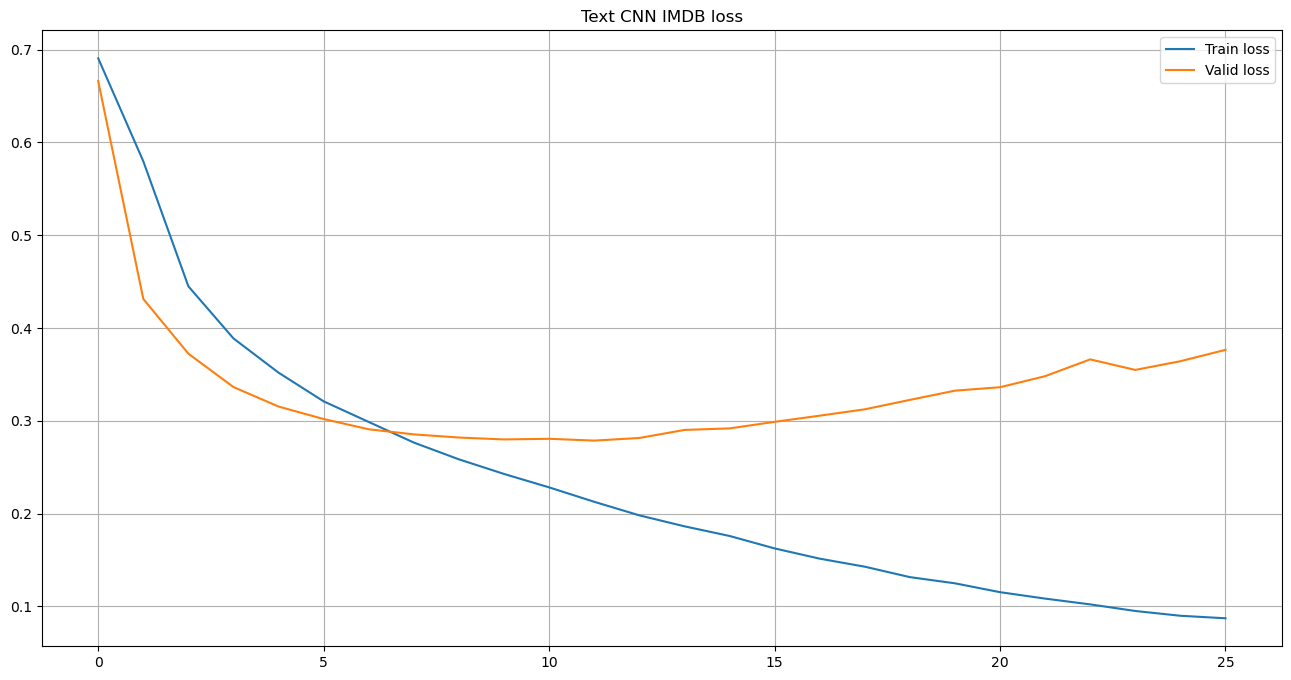

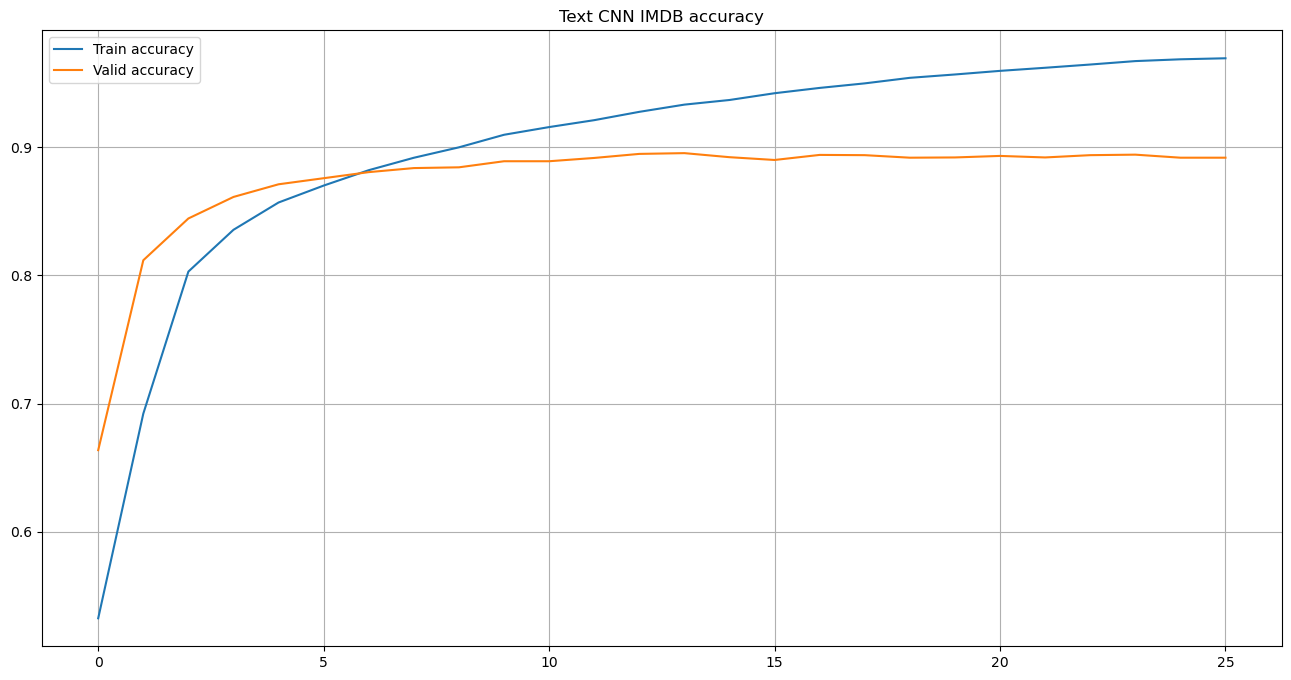

Train:  62%|█████████████████████████████████████████████▏                           | 436/704 [00:11<00:07, 36.81it/s]


KeyboardInterrupt: 

In [321]:
#!g1.1
model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)

whole_train_valid_cycle(model, 50, 'Text CNN IMDB')

In [287]:
@torch.inference_mode()
def predict(model, loader):
    model.eval()

    preds = []

    for batch  in tqdm(loader, desc="Test"):
        x = batch[0].to(device)

        output = model(x)

        probs = torch.sigmoid(output)
        pred = torch.round(probs)

        preds.append(pred.cpu())

    preds = torch.cat(preds).squeeze()

    return preds

In [288]:
test_preds = predict(model, test_loader)

print(test_preds.shape)

Test: 100%|████████████████████████████████████████████████████████████████████████████| 79/79 [00:01<00:00, 73.83it/s]

torch.Size([5000])


In [289]:
torch.save(test_preds, "test_predictions.pt")

In [290]:
test_preds

tensor([0., 0., 1.,  ..., 1., 1., 1.])